<a href="https://colab.research.google.com/github/nandhanandha6151-sys/CSR-projects-by-companies-2y/blob/main/PYTHON_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSR PROJECTS BY COMPANIES

Final Project in Data Analytics

# **Objective(Problem statment)**

1. To identify the top CSR spending companies.
2. To analyze state-wise and sector-wise CSR distribution.

3. To study the trends in CSR spending.
5. To generate data driven for companies and policymakers

# Outcome

This project aims to provide valuable insights into CSR spending patterns by analyzing company contributions, sector-wise distribution, and regional impact using data analytics techniques.

# Domain
Social Welfare

#**Dataset Information**

**Source:** India Data Portal /
<font color="blue"><u> **https://indiadataportal.com/p/corporate-social-responsibility-csr/r/mca-csr_projects-dt-yr-iuo**</font></u>

**Year / Timeline:** 2014 - 2020

**Dataset Column/features Description:**

* **Id**-Id of the projects
* **Year**- Years
* **State Name** -Name of the state
* **State Code**-Code of the state
* **District Name**-Name of the district
* **District Code**-Code of the district
* **CSR Project Name**-Name of the project
* **Development Sector**-Social sector of project
* **Company Name**-Name of the company
* **cin**-Company identification number
* **Company Class**-Class of the company
* **Company Type**-Type of the company
* **roc**-Registrar of companies
* **Company_Category**-Category of the company
* **Listing Status**-List of the status
* **Project Outlay Amount in Lakhs**-Mony budjeted by the company
* **Amount Spent in Lakhs**-Actual ammount spent


# **Inital EDA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/nandhanandha6151-sys/CSR-projects-by-companies-2y/refs/heads/main/csr-projects-by-companies%202y.csv")
df.head()

,id,year,state_name,state_code,district_name,district_code,csr_project_name,development_sector,company_name,cin,company_class,company_type,roc,company_category,listing_status,project_outlay_amount_in_lakhs,amount_spent_in_lakhs
0,0,1/1/2014,Jammu and Kashmir,1,Not Mentioned,0,Not Mentioned,Conservation Of Natural Resources,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,40.0,5.0
1,1,1/1/2014,Maharashtra,27,Not Mentioned,0,Not Mentioned,Education,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,24.0,20.0
2,2,1/1/2014,Karnataka,29,Not Mentioned,0,Not Mentioned,Education,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,24.0,20.0
3,3,1/1/2014,Karnataka,29,Not Mentioned,0,Not Mentioned,Women Empowerment,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,32.0,0.0
4,4,1/1/2014,Karnataka,29,Not Mentioned,0,Not Mentioned,Special Education,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,40.0,5.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36664 entries, 0 to 36663
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              36664 non-null  int64  
 1   year                            36664 non-null  object 
 2   state_name                      36664 non-null  object 
 3   state_code                      36664 non-null  int64  
 4   district_name                   36664 non-null  object 
 5   district_code                   36664 non-null  int64  
 6   csr_project_name                36661 non-null  object 
 7   development_sector              36664 non-null  object 
 8   company_name                    36664 non-null  object 
 9   cin                             36664 non-null  object 
 10  company_class                   36664 non-null  object 
 11  company_type                    36664 non-null  object 
 12  roc                             

In [4]:
df.columns

Index(['id', 'year', 'state_name', 'state_code', 'district_name',
       'district_code', 'csr_project_name', 'development_sector',
       'company_name', 'cin', 'company_class', 'company_type', 'roc',
       'company_category', 'listing_status', 'project_outlay_amount_in_lakhs',
       'amount_spent_in_lakhs'],
      dtype='object')

In [5]:
df.shape

(36664, 17)

In [6]:
df.describe()

,id,state_code,district_code,project_outlay_amount_in_lakhs,amount_spent_in_lakhs
count,36664.000000,36664.000000,36664.000000,3.666400e+04,36664.000000
mean,18798.843170,19.386155,131.495091,1.239896e+06,155.563992
std,10834.298102,16.152330,212.655448,5.723989e+07,1077.844685
min,0.000000,0.000000,0.000000,-2.000000e+01,-63.000000
25%,9353.750000,7.000000,0.000000,2.000000e+00,2.000000
50%,18839.500000,24.000000,0.000000,1.250000e+01,10.000000
75%,28202.250000,27.000000,315.000000,6.770500e+01,50.000000
max,37465.000000,99.000000,733.000000,6.632645e+09,55389.000000


In [7]:
df['project_outlay_amount_in_lakhs'].describe()

,project_outlay_amount_in_lakhs
count,3.666400e+04
mean,1.239896e+06
std,5.723989e+07
min,-2.000000e+01
25%,2.000000e+00
50%,1.250000e+01
75%,6.770500e+01
max,6.632645e+09


#**Key Insights**

The project_outlay_amount_in_lakhs variable shows a highly skewed distribution with significant variations in project costs. Although the average project outlay is very high, the median value indicates that most projects have relatively low investments. The presence of extremely large outlier values greatly affects the mean and standard deviation. Additionally, negative outlay values suggest potential data quality issues that should be addressed before further analysis.

In [8]:
df['amount_spent_in_lakhs'].describe()

,amount_spent_in_lakhs
count,36664.000000
mean,155.563992
std,1077.844685
min,-63.000000
25%,2.000000
50%,10.000000
75%,50.000000
max,55389.000000


#**Key Insights**

The amount_spent_in_lakhs variable shows a highly right-skewed distribution with significant outliers. Although the average spending is 155.56 lakhs, the median is only 10 lakhs, indicating that most customers spend relatively low amounts while a small number of customers spend extremely high amounts. The maximum value of 55,389 lakhs and the very high standard deviation (1077.84) further confirm the presence of extreme outliers. Additionally, the minimum value of –63 lakhs suggests the existence of negative values, which may represent refunds, data entry errors, or cancellations and should be investigated during data cleaning.

In [9]:
df.describe(include="object")

,year,state_name,district_name,csr_project_name,development_sector,company_name,cin,company_class,company_type,roc,company_category,listing_status
count,36664,36664,36664,36661,36664,36664,36664,36664,36664,36664,36664,36664
unique,7,37,487,20713,29,693,693,3,2,28,3,2
top,1/1/2019,Maharashtra,Not Mentioned,Not Mentioned,Education,Container Corporation Of India Limited,L63011DL1988GOI030915,Public,Other than Govt. Companies,ROC-MUMBAI,Company limited by Shares,Listed
freq,6234,7037,24277,2054,10376,294,294,36455,32748,10959,36558,36461


## Data Cleaning and Pre-processing


In [10]:
df.isnull().sum()

,0
id,0
year,0
state_name,0
state_code,0
district_name,0
district_code,0
csr_project_name,3
development_sector,0
company_name,0
cin,0


In [11]:
df=df.dropna()

In [12]:
df.isnull().sum()

,0
id,0
year,0
state_name,0
state_code,0
district_name,0
district_code,0
csr_project_name,0
development_sector,0
company_name,0
cin,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop(columns=['id'],inplace=True)

In [15]:
df.head()

,year,state_name,state_code,district_name,district_code,csr_project_name,development_sector,company_name,cin,company_class,company_type,roc,company_category,listing_status,project_outlay_amount_in_lakhs,amount_spent_in_lakhs
0,1/1/2014,Jammu and Kashmir,1,Not Mentioned,0,Not Mentioned,Conservation Of Natural Resources,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,40.0,5.0
1,1/1/2014,Maharashtra,27,Not Mentioned,0,Not Mentioned,Education,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,24.0,20.0
2,1/1/2014,Karnataka,29,Not Mentioned,0,Not Mentioned,Education,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,24.0,20.0
3,1/1/2014,Karnataka,29,Not Mentioned,0,Not Mentioned,Women Empowerment,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,32.0,0.0
4,1/1/2014,Karnataka,29,Not Mentioned,0,Not Mentioned,Special Education,3m India Limited,L31300KA1987PLC013543,Public,Other than Govt. Companies,ROC-BANGALORE,Company limited by Shares,Listed,40.0,5.0


In [16]:
df['company_class'].value_counts()

,count
company_class,
Public,36452
Private,185
PLC,24


In [17]:
df['company_type'].value_counts()

,count
company_type,
Other than Govt. Companies,32745
Govt. Companies,3916


In [18]:
df['company_category'].value_counts()

,count
company_category,
Company limited by Shares,36555
Company Limited by Guarantee,62
Non-govt company,44


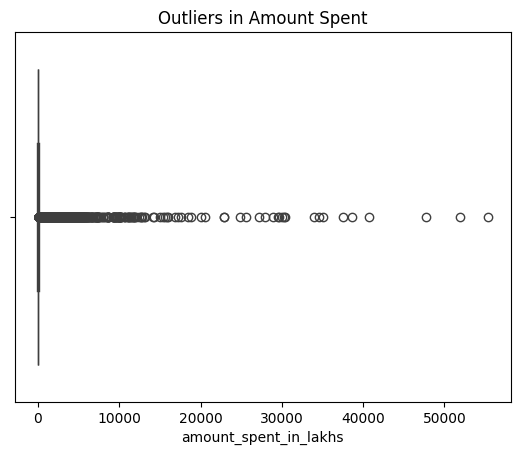

In [19]:
sns.boxplot(x=df['amount_spent_in_lakhs'])
plt.title('Outliers in Amount Spent')
plt.show()

In [20]:
Q1 = df['amount_spent_in_lakhs'].quantile(0.25)
Q3 = df['amount_spent_in_lakhs'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df['amount_spent_in_lakhs'] < lower_bound) | (df['amount_spent_in_lakhs'] > upper_bound)]
print(f"Total outliers: {len(outliers)}")

Total outliers: 5275


In [21]:

df_cleaned = df[(df['amount_spent_in_lakhs'] >= 0) & (df['amount_spent_in_lakhs'] <= upper_bound)]

In [22]:


df['amount_spent_in_lakhs'] = np.where(df['amount_spent_in_lakhs'] < 0, 0, df['amount_spent_in_lakhs'])

df['amount_spent_in_lakhs'] = np.where(df['amount_spent_in_lakhs'] > upper_bound, upper_bound, df['amount_spent_in_lakhs'])

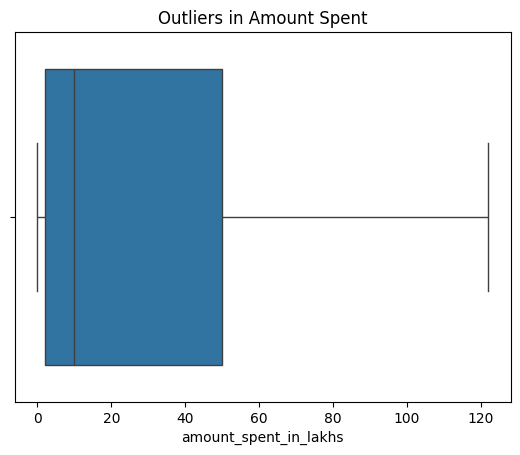

In [23]:
sns.boxplot(x=df['amount_spent_in_lakhs'])
plt.title('Outliers in Amount Spent')
plt.show()

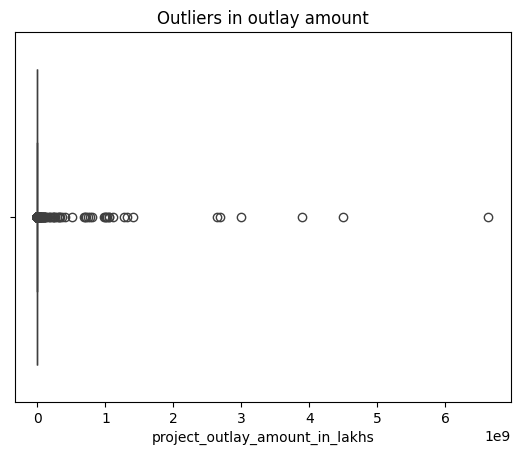

In [24]:
sns.boxplot(x=df['project_outlay_amount_in_lakhs'])
plt.title('Outliers in outlay amount')
plt.show()

In [25]:
Q1 = df['project_outlay_amount_in_lakhs'].quantile(0.25)
Q3 = df['project_outlay_amount_in_lakhs'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df['project_outlay_amount_in_lakhs'] < lower_bound) | (df['project_outlay_amount_in_lakhs'] > upper_bound)]
print(f"Total outliers: {len(outliers)}")

Total outliers: 5799


In [26]:

df_cleaned = df[(df['project_outlay_amount_in_lakhs'] >= 0) & (df['project_outlay_amount_in_lakhs'] <= upper_bound)]

In [27]:
df['project_outlay_amount_in_lakhs'] = np.where(df['project_outlay_amount_in_lakhs'] < 0, 0, df['project_outlay_amount_in_lakhs'])

df['project_outlay_amount_in_lakhs'] = np.where(df['project_outlay_amount_in_lakhs'] > upper_bound, upper_bound, df['project_outlay_amount_in_lakhs'])

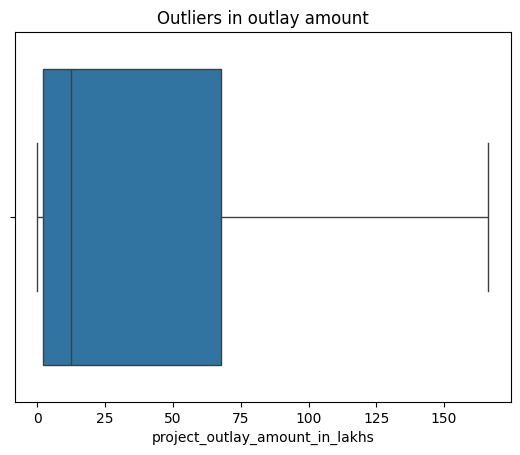

In [28]:
sns.boxplot(x=df['project_outlay_amount_in_lakhs'])
plt.title('Outliers in outlay amount')
plt.show()

In [29]:

df['log_amount_spent'] = np.log1p(df['amount_spent_in_lakhs'])

In [30]:
df.skew(numeric_only=True)

,0
state_code,1.883752
district_code,1.189261
project_outlay_amount_in_lakhs,1.198953
amount_spent_in_lakhs,1.214427
log_amount_spent,0.009141


In [31]:
df['amount_spent_in_lakhs'].skew()

np.float64(1.2144270861035416)

In [32]:
df['project_outlay_amount_in_lakhs'].skew()

np.float64(1.1989528442927082)

#1. Distribution of Development Sector (Countplot)

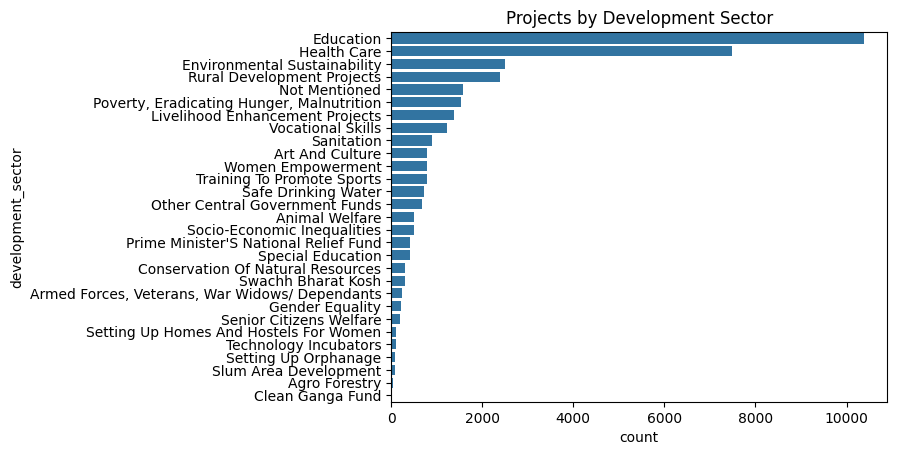

In [33]:

sns.countplot(data=df, y='development_sector',
              order=df['development_sector'].value_counts().index)
plt.title("Projects by Development Sector")
plt.show()

### **Insights**

* Education has the highest number of CSR projects, followed by Health Care.
* Environmental Sustainability and Rural Development receive a moderate number of projects.
* Sectors like Women Empowerment, Sanitation, and Vocational Skills have comparatively fewer projects.
* Clean Ganga Fund, Agro Forestry, Slum Area Development, Technology Incubators, and Orphanage Setup have the lowest number of CSR projects.

* Overall, CSR projects are concentrated in a few major sectors, while many other sectors receive limited project support.

## Interpretation of your above chart

1. Explain the Chart.

This chart shows the number of CSR projects in each development sector.

2. What is it saying?

Some development sectors receive significantly more CSR projects than others.

3. What features you used?

development_sector

4. From this what you are showing us?

The company preference for different CSR sectors.

#2. Project Outlay Distribution (Histogram)

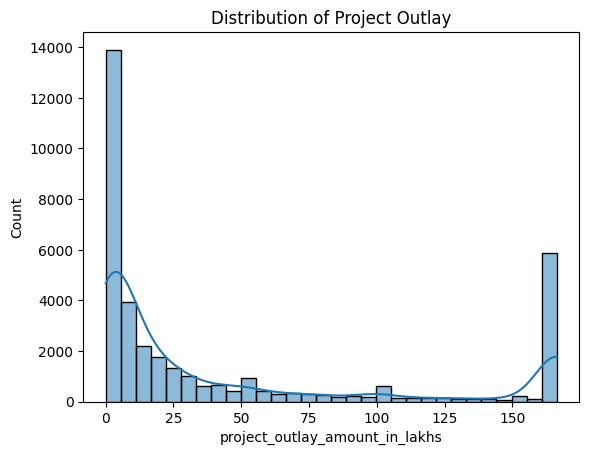

In [34]:
sns.histplot(df['project_outlay_amount_in_lakhs'], bins=30, kde=True)
plt.title("Distribution of Project Outlay")
plt.show()

### **Insights**

* Most CSR projects have low project outlay.
* The distribution is right-skewed.
* Very few projects have high budget allocation.
* A large number of projects are concentrated in the 0–25 lakhs range.
* Some projects have very large outlays, showing outliers in the dataset.
* The KDE curve also confirms that the data is not evenly distributed.

## Interpretation of your above chart

1. Explain the Chart.

Shows how project budgets are distributed.

2. What is it saying?

Most projects have smaller budgets while only a few have very large budgets.

3. What features you used?

project_outlay_amount_in_lakhs

4. From this what you are showing us?

Overall CSR budget distribution.


#3. Amount Spent Distribution (Boxplot)

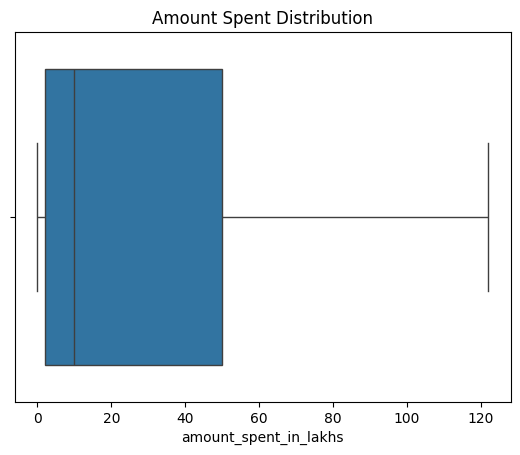

In [35]:
sns.boxplot(x=df['amount_spent_in_lakhs'])
plt.title("Amount Spent Distribution")
plt.show()

### **Insights**

*  Most CSR spending falls within the lower to mid-range values.
*  The median spending is lower than the maximum spending.
*  Spending amounts vary significantly across projects.
* A few projects have very high CSR expenditure.
* The data shows a wide range of CSR spending distribution.

## Interpretation of your above chart

1. Explain the Chart.

Showing the distribution of Amount Spent (in Lakhs) on CSR projects.

2. What is it saying?

Most CSR spending values are concentrated in the lower to middle range, while a few projects have much higher spending amounts.

3. What features you used?

amount_spent_in_lakhs

4. From this what you are showing us?

Overall distribution of CSR spending, identifies the typical spending range, and shows the presence of higher-value spending projects.



#4.Top 10 States by Total CSR Spending

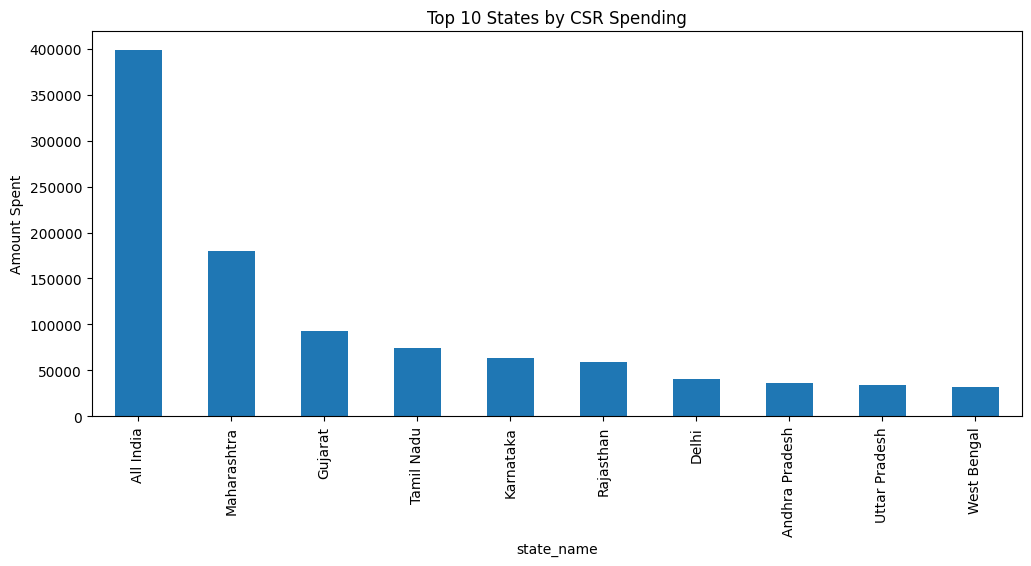

In [36]:
top=df.groupby('state_name')['amount_spent_in_lakhs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top.plot(kind='bar')
plt.title("Top 10 States by CSR Spending")
plt.ylabel("Amount Spent")
plt.show()

### **Insights**

* All India records the highest CSR spending, significantly higher than all other categories.
* Maharashtra ranks second, making it the leading state in CSR expenditure.
* Gujarat and Tamil Nadu also receive substantial CSR funding, ranking among the top contributors.
* Karnataka and Rajasthan show moderate CSR spending compared to the top states.
* Delhi, Andhra Pradesh, Uttar Pradesh, and West Bengal have the lowest CSR spending among the top 10 states.

## Interpretation of your above chart

1. Explain the Chart.

Shows which states receive the highest CSR spending.

2. What is it saying?

 States by total CSR spending is most high spend in All india

3. What features you used?

state_name

4. From this what you are showing us?

Top 10 States total CSR spending ammount lists

#5. Project Outlay vs Amount Spent (Scatterplot)

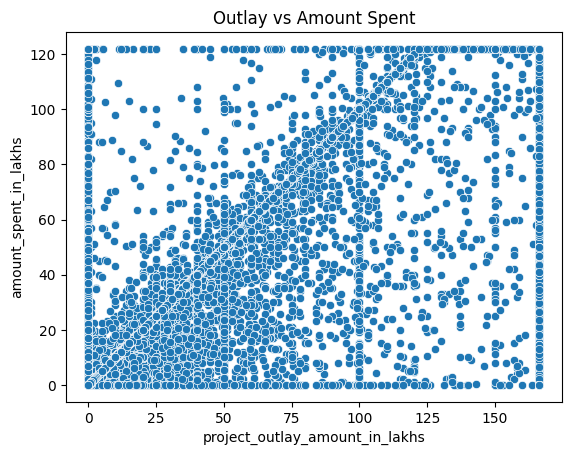

In [37]:
sns.scatterplot(data=df,
                x='project_outlay_amount_in_lakhs',
                y='amount_spent_in_lakhs')
plt.title("Outlay vs Amount Spent")
plt.show()

### **Insights**

* Higher project outlay generally leads to higher CSR spending.
* Most projects follow a positive spending trend.
* Some projects spend less despite having high outlay.
* Spending varies across projects, indicating different utilization levels.
* The chart helps identify the relationship between budget allocation and actual spending.

## Interpretation of your above chart

1. Explain the Chart.

Shows relationship between allocated and spent amount

2. What is it saying?

 Project Outlay and Amount Spent was strong positive relationship.

3. What features/columns you used?

project_outlay_amount_in_lakhs

amount_spent_in_lakhs

4. From this what you are showing us?

This chart helps us understand how the allocated CSR budget relates to the actual spending.

#6. Correlation Heatmap

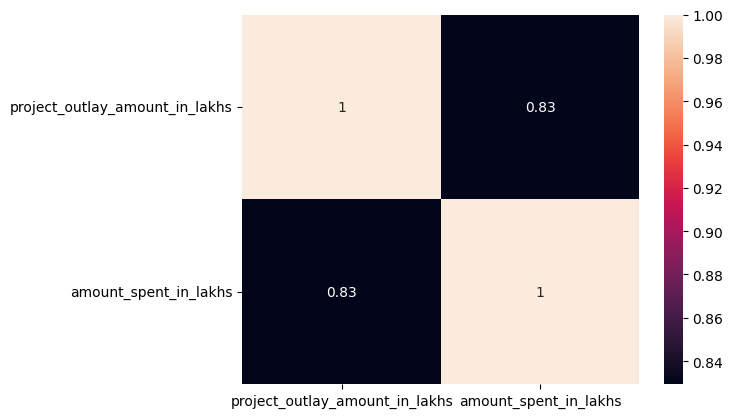

In [38]:
sns.heatmap(df[['project_outlay_amount_in_lakhs',
                'amount_spent_in_lakhs']].corr(),
            annot=True,
           )
plt.show()

### **Insights**

* Strong positive correlation (0.83) between project outlay and amount spent.
* Higher project budgets generally lead to higher spending.
* Most CSR projects utilize the allocated budget effectively.
* Budget allocation is closely linked to actual expenditure.
* The chart helps understand CSR spending patterns and financial planning.

## Interpretation of your above chart

1. Explain the Chart.

This heatmap shows the correlation between the two numerical variables: Project Outlay Amount and Amount Spent.

2. What is it saying?

That projects with higher allocated budgets generally have higher actual spending.

3. What features/columns you used?

project_outlay_amount_in_lakhs

amount_spent_in_lakhs

4. From this what you are showing us?

 The strength of the relationship between the allocated CSR budget and the actual amount spent.

#7. Company Type vs Average Spending

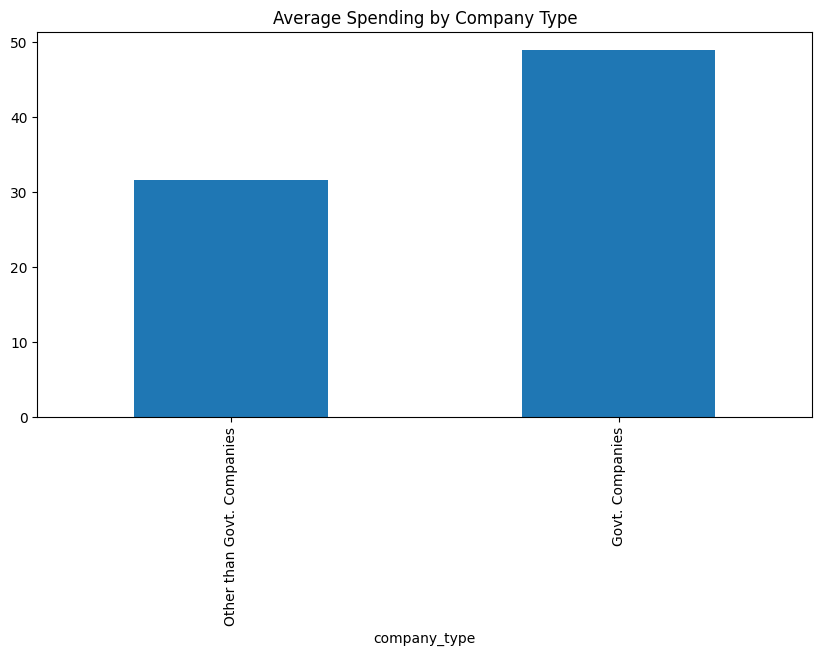

In [39]:
avg=df.groupby('company_type')['amount_spent_in_lakhs'].mean().sort_values()

plt.figure(figsize=(10,5))
avg.plot(kind='bar')
plt.title("Average Spending by Company Type")
plt.show()

### **Insights**

* Govt. Companies have the highest average CSR spending.
* Other than Govt. Companies spend less on average.
* There is a clear difference in spending between the two company types.
* Company type plays an important role in CSR investment.
* Govt. Companies appear to be more active in higher-value CSR spending.

## Interpretation of your above chart

1. Explain the Chart.

Average CSR spending for two company types: Govt. Companies and Other than Govt. Companies.

2. What is it saying?

Govt. Companies spend more on average than Other than Govt. Companies.

3. What features/columns you used?

company_type

amount_spent_in_lakhs

4. From this what you are showing us?

Shows that company type affects CSR spending. It helps compare which type of company contributes more on average to CSR projects.

#8. Year-wise CSR Spending Trend

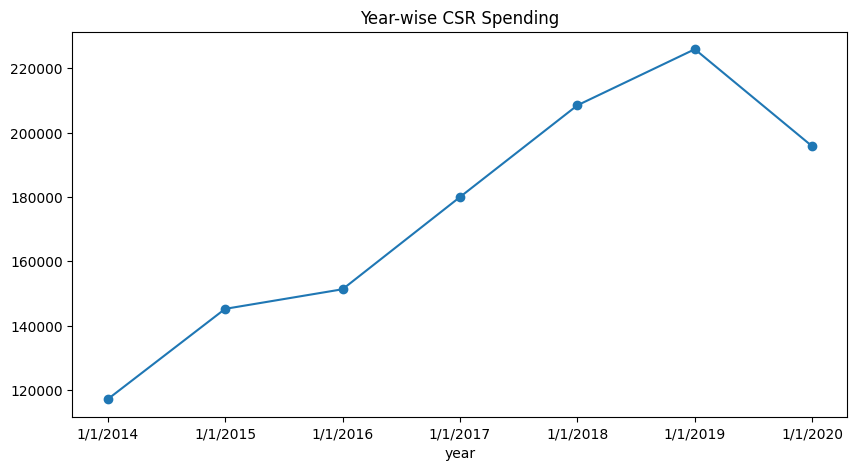

In [40]:
year=df.groupby('year')['amount_spent_in_lakhs'].sum()

plt.figure(figsize=(10,5))
year.plot(marker='o')
plt.title("Year-wise CSR Spending")
plt.show()

### **Insights**

* CSR spending increased steadily from 2014 to 2019.
* 2019 recorded the highest CSR spending.
* CSR spending declined in 2020 compared to 2019.
* Overall, CSR investment showed a positive growth trend over the years.
* The chart helps identify annual CSR spending patterns and trends.

## Interpretation of your above chart

1. Explain the Chart.

The total CSR spending across different years (2014–2020). It helps visualize how CSR expenditure has changed over time.

2. What is it saying?

CSR spending steadily increased from 2014 to 2019, reaching its highest level in 2019. In 2020, CSR spending decreased compared to 2019.

3. What features/columns you used?

year

amount_spent_in_lakhs

4. From this what you are showing us?

trend of CSR spending over the years. It helps identify years with the highest and lowest CSR expenditure and understand how CSR investment has changed over time.

#9. Listing Status Count

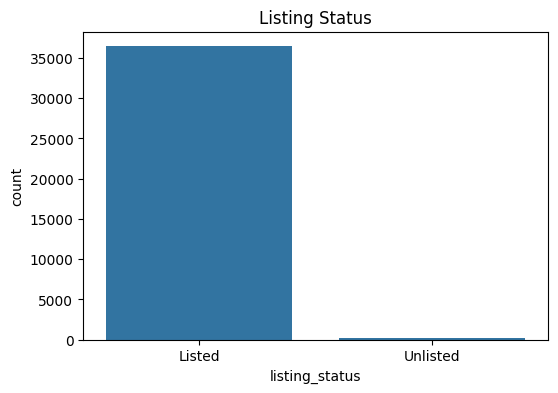

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='listing_status')
plt.title("Listing Status")
plt.show()

### **Insights**

* Listed companies dominate the dataset.
* Unlisted companies have very few records.
* CSR analysis is mainly based on Listed companies.
* The dataset is highly imbalanced between Listed and Unlisted companies.
* Listed companies contribute the majority of observations.

## Interpretation of your above chart

1. Explain the Chart.

The number of companies based on their listing status. It compares two categories: Listed and Unlisted companies.

2. What is it saying?

Listed companies are much higher in number than Unlisted companies in the dataset.

3. What features/columns you used?

listing_status (X-axis)

Count/Frequency (Y-axis)

4. From this what you are showing us?

Shows the distribution of companies by listing status and indicates that most CSR records belong to Listed companies.


#10. Top 10 Companies by CSR Spending

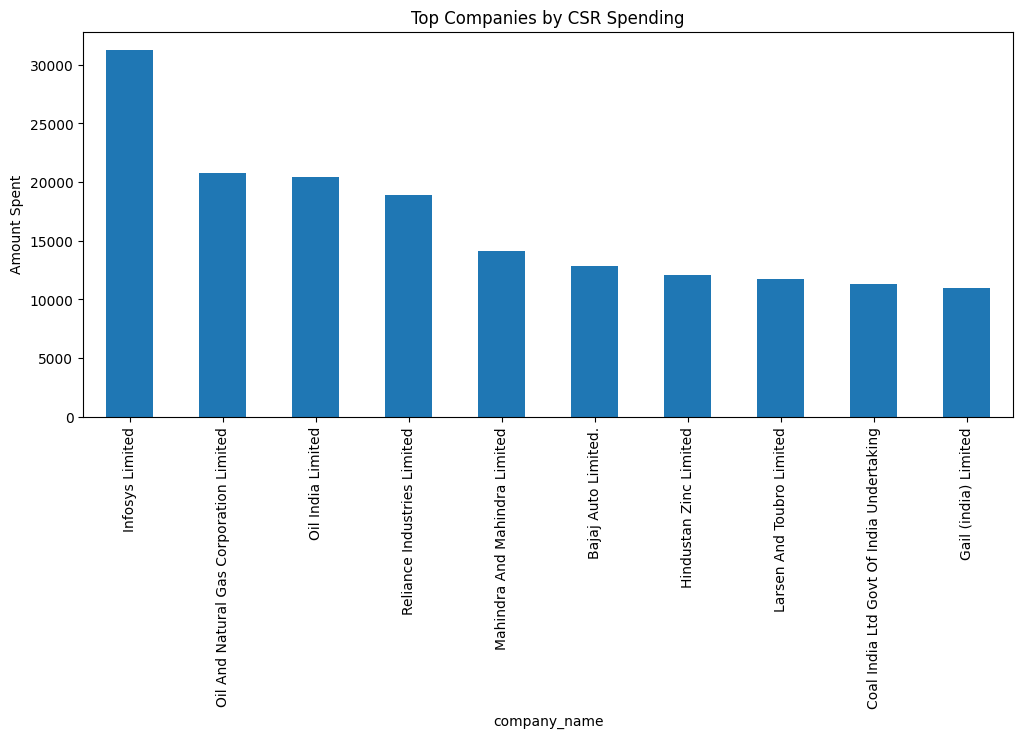

In [42]:
top=df.groupby('company_name')['amount_spent_in_lakhs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top.plot(kind='bar')
plt.title("Top Companies by CSR Spending")
plt.ylabel("Amount Spent")
plt.show()

### **Insights**

* Infosys Limited is the highest CSR spender.
* ONGC, Oil India, and Reliance are among the top CSR contributors.
* CSR spending varies significantly across companies.
* The top few companies contribute much more than the others.
* The chart helps identify the leading CSR-performing companies.

## Interpretation of your above chart

1. Explain the Chart.

Top 10 Companies by CSR Spending. The X-axis represents the company names, and the Y-axis represents the CSR amount spent.

2. What is it saying?

That Infosys Limited has the highest CSR spending among the top companies. Oil and Natural Gas Corporation (ONGC), Oil India Limited, and Reliance Industries Limited also have high CSR spending, while the remaining companies spend comparatively less.

3. What features/columns you used?

company_name (X-axis)

amount_spent_in_lakhs (Y-axis)

4. From this what you are showing us?

Identifies the top companies based on CSR expenditure and compares how much each company spends on CSR activities.

In [43]:
df.to_csv("CSR_Cleaned_Data.csv", index=False)

In [44]:
from google.colab import files
files.download("CSR_Cleaned_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

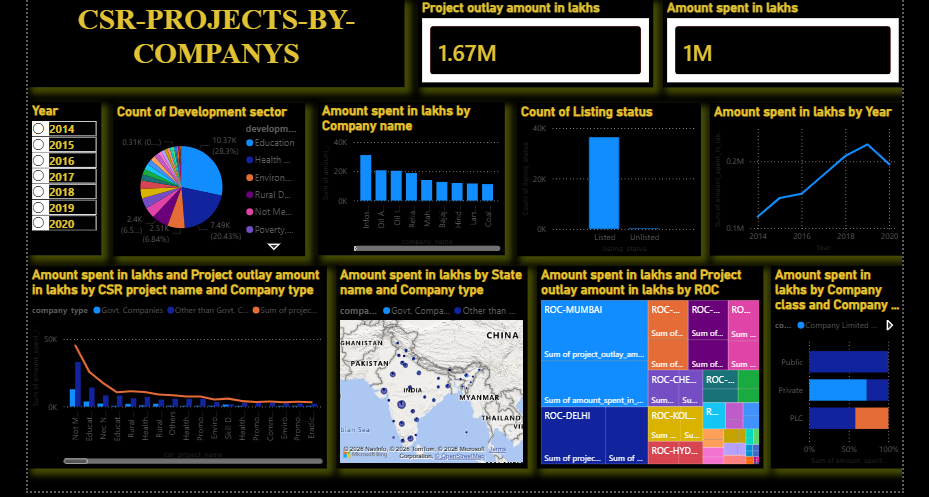

## **Final Overall Insights:**
* This CSR (corporate social responsibility) activities carried out by companies across different years, sectors, states, and company categories. The analysis shows that companies allocated a total project outlay of approximately 1.67 million lakhs, while around 1 million lakhs was actually spent on CSR projects.
* This indicates that although significant budgets were planned, not all allocated funds were utilized. It was also reveals that Education and Healthcare are the most preferred development sectors, highlighting the strong focus of companies on improving social welfare.
* A diagnostic analysis suggests that the gap between allocated and actual expenditure may be due to project implementation delays, incomplete project execution, regulatory approvals, or operational challenges that prevented companies from fully utilizing their CSR budgets within the reporting period.
* This also reveals that Education and Healthcare are the most preferred development sectors, highlighting the strong focus of companies on improving social welfare, as these sectors create long-term social impact and align closely with national development priorities.
* Listed companies contribute a major share of CSR spending, reflecting their greater compliance with CSR regulations and stronger financial capacity. The year-wise trend shows a steady increase in CSR expenditure from 2014 to 2019, demonstrating growing corporate commitment towards social development, followed by a slight decline in 2020.
* The analysis across states and ROC regions indicates that CSR investments are concentrated in a few locations, while some regions receive comparatively lower funding. Looking at the current trends, CSR investments are likely to continue increasing in the coming years, especially in high-impact sectors such as Education and Healthcare.
* To maximize the effectiveness of CSR initiatives, companies should improve project monitoring, reduce the gap between allocated and actual spending, ensure timely utilization of funds, and distribute CSR investments more evenly across sectors and regions.
* Overall, this also helps stakeholders understand CSR spending patterns, identify improvement areas, and make better data-driven decisions for future CSR planning.

# Future Enhancement

* Predictive Analytics: Use Machine Learning to forecast future CSR spending trends and identify projects at risk of under-utilizing their budget.
* Advanced Geo-Mapping: Add interactive GIS maps and heatmaps to easily pinpoint underfunded regions and districts that need more support.
* Real-time Data Updates: Connect the dashboard to live APIs (like government CSR portals) for automatic, real-time data streaming.
* Social Impact Tracking: Introduce qualitative KPIs (e.g., number of students educated or patients treated) to measure actual ground-level impact alongside financial spend.

# Conclusion

This CSR Dashboard serves as a vital data-driven tool that helps stakeholders bridge the gap between allocated budgets and actual spending. By highlighting sectoral preferences and regional imbalances, it provides actionable insights to optimize fund distribution and maximize social welfare. Ultimately, this analysis empowers companies to make smarter, highly compliant, and impactful decisions for future CSR planning.